__LRG_OPT and LRG_IR as defined in the updated selection__

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
zbest_path = '/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/alltiles_LRGzinfo_mw_trans_added.fits'
tmp = fitsio.read(zbest_path, columns=['TARGETS'])
idx = np.where(tmp['TARGETS']=='QSO+LRG')[0]
zbest = Table(fitsio.read(zbest_path, rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

674227
37119


In [4]:
deep = zbest.copy()

# Select deep coadds
mask = deep['subset']=='deep'
print(np.sum(mask))
# # Select QSO+LRG tiles
# mask &= deep['TARGETS']=='QSO+LRG'
# print(np.sum(mask))
deep = deep[mask]

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove "no data" fibers
mask = deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = deep['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

# # Ting-Wen's quality cuts
# mask = deep['DELTACHI2']>20
# mask &= deep['Z']<1.4
# mask &= deep['ZWARN']==0
# print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# deep = deep[mask]

print(len(deep))
print(len(np.unique(deep['TARGETID'])))

deep_columns_old = ['Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'SUBTYPE', 'DELTACHI2', 'B_DEPTH_EBVAIR', 'R_DEPTH_EBVAIR', 'Z_DEPTH_EBVAIR', 'EFFTIME_DARK', 'EFFTIME_BRIGHT', 'EFFTIME_BACK']
deep_columns_new = ['Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'SUBTYPE_deep', 'DELTACHI2_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep', 'EFFTIME_DARK_deep', 'EFFTIME_BRIGHT_deep', 'EFFTIME_BACK_deep']
deep.rename_columns(deep_columns_old, deep_columns_new)

34868
FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05
Min depth 18686 10684 0.636227442969016
18686
18686


In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    deep['gmag'] = 22.5 - 2.5*np.log10(deep['FLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rmag'] = 22.5 - 2.5*np.log10(deep['FLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zmag'] = 22.5 - 2.5*np.log10(deep['FLUX_Z']/deep['MW_TRANSMISSION_Z'])
    deep['w1mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W1']/deep['MW_TRANSMISSION_W1'])
    deep['w2mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W2']/deep['MW_TRANSMISSION_W2'])
    deep['gfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']/deep['MW_TRANSMISSION_Z'])

In [6]:
mask = zbest['RZR']=='single_exposures'
zbest = zbest[mask]
print(len(zbest))

mask = np.in1d(zbest['TARGETID'], deep['TARGETID'])
zbest = zbest[mask]
print(len(zbest))

print(len(np.unique(zbest['TARGETID'])))

deep_columns = deep_columns_new+['TARGETID', 'gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'gfibermag', 'rfibermag', 'zfibermag']
zbest = join(zbest, deep[deep_columns], keys='TARGETID')

429668
238615
18686


In [7]:
zbest['EXPID'] = np.array(zbest['subset'], dtype=int)

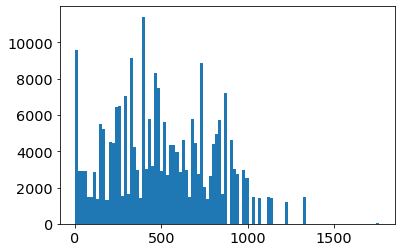

45461 0.19052029419776628


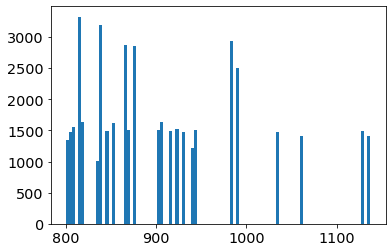

907.5743860022511
876.72216796875


In [8]:
plt.hist(zbest['EFFTIME_DARK'], 100)
plt.show()

mask = (zbest['EFFTIME_DARK'] > 800) & (zbest['EFFTIME_DARK'] < 1200)
print(np.sum(mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

plt.hist(zbest['EFFTIME_DARK'], 100)
plt.show()

print(np.mean(zbest['EFFTIME_DARK']))
print(np.median(zbest['EFFTIME_DARK']))

In [9]:
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

45461
15748


In [10]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [11]:
# Baseline (600/sqdeg) IR selection without the high-z extension (zfiber<21.5)
# Same as LRG_IR in v1.3

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.27) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg0_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.23) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg0_north = lrg_mask.copy()

lrg0 = lrg0_south | lrg0_north
print(np.sum(lrg0))

12748


In [12]:
# zfiber & sliding cut extension; 800 targets/sq.deg.

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.26) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.36) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.29
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.3) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.13)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.72)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.24) * 1.83 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.34) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.23)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_north = lrg_mask.copy()

lrg_sv3 = lrg_sv3_south | lrg_sv3_north
print(np.sum(lrg_sv3))

########################################################################

# zfiber & sliding cut extension; 600 targets/sq.deg.

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.07) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.17) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.3) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.13)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_lowdens_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.72)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.05) * 1.83 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.14) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.49
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.34) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.23)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_lowdens_north = lrg_mask.copy()

lrg_sv3_lowdens = lrg_sv3_lowdens_south | lrg_sv3_lowdens_north
print(np.sum(lrg_sv3_lowdens))

16689
12501


In [13]:
print('Total # exposures in this analysis:', len(np.unique(zbest['EXPID'])))
t = Table()
t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
t['n_exp'] = 0
for index, tileid in enumerate(t['TILEID']):
    mask = zbest['TILEID']==tileid
    t['n_exp'][index] = len(np.unique(zbest['EXPID'][mask]))
t

Total # exposures in this analysis: 32


TILEID,count,n_exp
int64,int64,int64
80605,6153,4
80607,8740,6
80609,8181,5
80620,4086,3
80622,3673,3
80678,1348,1
80680,4435,3
80688,3005,2
80690,1316,1


--------

In [14]:
mask_zwarn = (zbest['ZWARN_deep']==0)

# Not repeatable
zdiff_threshold = 0.0033
mask_fail = np.abs((zbest['Z'] - zbest['Z_deep'])/(1 + zbest['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
# Also include objects with ZWARN!=0 in the deep coadds
mask_fail |= (~mask_zwarn)
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))

4242 0.09331074987351796
4295 0.09447658432502584


In [15]:
print('Overall failure rates:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum(lrg0 & mask_fail)/np.sum(lrg0)*100, np.sum(lrg0 & mask_fail), np.sum(lrg0)))
print('SV3: {:.1f}% ({}/{})'.format(np.sum(lrg_sv3 & mask_fail)/np.sum(lrg_sv3)*100, np.sum(lrg_sv3 & mask_fail), np.sum(lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum(lrg_sv3_lowdens & mask_fail)/np.sum(lrg_sv3_lowdens)*100, np.sum(lrg_sv3_lowdens & mask_fail), np.sum(lrg_sv3_lowdens)))

Overall failure rates:
Previous IR sample: 2.6% (331/12748)
SV3: 4.2% (693/16689)
SV3 subsample:  4.2% (523/12501)


In [16]:
# ZWARN cut on single exposures
mask_quality = zbest['ZWARN']==0

print('Fraction removed:')
print('Previous IR sample: {:.1f}%'.format(np.sum((~mask_quality) & lrg0)/np.sum(lrg0)*100))
print('SV3:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3)/np.sum(lrg_sv3)*100))
print('SV3 subsample:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3_lowdens)/np.sum(lrg_sv3_lowdens)*100))
print()

print('Overall failure rates:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg0 & mask_fail)/np.sum(mask_quality & lrg0)*100, np.sum(mask_quality & lrg0 & mask_fail), np.sum(mask_quality & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3 & mask_fail)/np.sum(mask_quality & lrg_sv3)*100, np.sum(mask_quality & lrg_sv3 & mask_fail), np.sum(mask_quality & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3_lowdens & mask_fail)/np.sum(mask_quality & lrg_sv3_lowdens)*100, np.sum(mask_quality & lrg_sv3_lowdens & mask_fail), np.sum(mask_quality & lrg_sv3_lowdens)))

Fraction removed:
Previous IR sample: 1.9%
SV3:  3.9%
SV3 subsample:  3.9%

Overall failure rates:
Previous IR sample: 1.4% (169/12505)
SV3:  1.9% (297/16041)
SV3 subsample:  1.8% (222/12009)


In [17]:
# ZWARN and redshift cuts on single exposures
mask_quality = zbest['ZWARN']==0
mask_quality &= zbest['Z']<1.4

print('Fraction removed:')
print('Previous IR sample: {:.1f}%'.format(np.sum((~mask_quality) & lrg0)/np.sum(lrg0)*100))
print('SV3:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3)/np.sum(lrg_sv3)*100))
print('SV3 subsample:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3_lowdens)/np.sum(lrg_sv3_lowdens)*100))
print()

print('Overall failure rates:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg0 & mask_fail)/np.sum(mask_quality & lrg0)*100, np.sum(mask_quality & lrg0 & mask_fail), np.sum(mask_quality & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3 & mask_fail)/np.sum(mask_quality & lrg_sv3)*100, np.sum(mask_quality & lrg_sv3 & mask_fail), np.sum(mask_quality & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3_lowdens & mask_fail)/np.sum(mask_quality & lrg_sv3_lowdens)*100, np.sum(mask_quality & lrg_sv3_lowdens & mask_fail), np.sum(mask_quality & lrg_sv3_lowdens)))

Fraction removed:
Previous IR sample: 2.4%
SV3:  4.5%
SV3 subsample:  4.7%

Overall failure rates:
Previous IR sample: 1.0% (128/12442)
SV3:  1.4% (227/15940)
SV3 subsample:  1.3% (160/11919)


In [18]:
# ZWARN, redshift, and DELTACHI2 cuts on single exposures

# Ting-Wen's quality cuts
mask_quality = zbest['DELTACHI2']>15
mask_quality &= zbest['Z']<1.4
mask_quality &= zbest['ZWARN']==0

print('Fraction removed:')
print('Previous IR sample: {:.1f}%'.format(np.sum((~mask_quality) & lrg0)/np.sum(lrg0)*100))
print('SV3:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3)/np.sum(lrg_sv3)*100))
print('SV3 subsample:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3_lowdens)/np.sum(lrg_sv3_lowdens)*100))
print()

print('Overall failure rates:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg0 & mask_fail)/np.sum(mask_quality & lrg0)*100, np.sum(mask_quality & lrg0 & mask_fail), np.sum(mask_quality & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3 & mask_fail)/np.sum(mask_quality & lrg_sv3)*100, np.sum(mask_quality & lrg_sv3 & mask_fail), np.sum(mask_quality & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3_lowdens & mask_fail)/np.sum(mask_quality & lrg_sv3_lowdens)*100, np.sum(mask_quality & lrg_sv3_lowdens & mask_fail), np.sum(mask_quality & lrg_sv3_lowdens)))

Fraction removed:
Previous IR sample: 3.2%
SV3:  6.4%
SV3 subsample:  6.6%

Overall failure rates:
Previous IR sample: 0.7% (92/12338)
SV3:  1.0% (158/15625)
SV3 subsample:  0.9% (108/11676)


In [19]:
# ZWARN, redshift, and DELTACHI2 cuts on single exposures

# Ting-Wen's quality cuts
mask_quality = zbest['DELTACHI2']>20
mask_quality &= zbest['Z']<1.4
mask_quality &= zbest['ZWARN']==0

print('Fraction removed:')
print('Previous IR sample: {:.1f}%'.format(np.sum((~mask_quality) & lrg0)/np.sum(lrg0)*100))
print('SV3:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3)/np.sum(lrg_sv3)*100))
print('SV3 subsample:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3_lowdens)/np.sum(lrg_sv3_lowdens)*100))
print()

print('Overall failure rates:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg0 & mask_fail)/np.sum(mask_quality & lrg0)*100, np.sum(mask_quality & lrg0 & mask_fail), np.sum(mask_quality & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3 & mask_fail)/np.sum(mask_quality & lrg_sv3)*100, np.sum(mask_quality & lrg_sv3 & mask_fail), np.sum(mask_quality & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3_lowdens & mask_fail)/np.sum(mask_quality & lrg_sv3_lowdens)*100, np.sum(mask_quality & lrg_sv3_lowdens & mask_fail), np.sum(mask_quality & lrg_sv3_lowdens)))

Fraction removed:
Previous IR sample: 3.8%
SV3:  8.0%
SV3 subsample:  8.3%

Overall failure rates:
Previous IR sample: 0.6% (75/12260)
SV3:  0.8% (120/15356)
SV3 subsample:  0.7% (84/11463)


In [20]:
# MEDIUM and WISE masks
maskbits = [8, 11]
mask_quality = np.ones(len(zbest), dtype=bool)
for bit in maskbits:
    mask_quality &= (zbest['MASKBITS'] & 2**bit)==0

print('Fraction removed:')
print('Previous IR sample: {:.1f}%'.format(np.sum((~mask_quality) & lrg0)/np.sum(lrg0)*100))
print('SV3:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3)/np.sum(lrg_sv3)*100))
print('SV3 subsample:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3_lowdens)/np.sum(lrg_sv3_lowdens)*100))
print()

print('Overall failure rates:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg0 & mask_fail)/np.sum(mask_quality & lrg0)*100, np.sum(mask_quality & lrg0 & mask_fail), np.sum(mask_quality & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3 & mask_fail)/np.sum(mask_quality & lrg_sv3)*100, np.sum(mask_quality & lrg_sv3 & mask_fail), np.sum(mask_quality & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3_lowdens & mask_fail)/np.sum(mask_quality & lrg_sv3_lowdens)*100, np.sum(mask_quality & lrg_sv3_lowdens & mask_fail), np.sum(mask_quality & lrg_sv3_lowdens)))

Fraction removed:
Previous IR sample: 7.3%
SV3:  7.0%
SV3 subsample:  7.2%

Overall failure rates:
Previous IR sample: 2.5% (301/11818)
SV3:  4.1% (640/15515)
SV3 subsample:  4.1% (476/11597)


---------

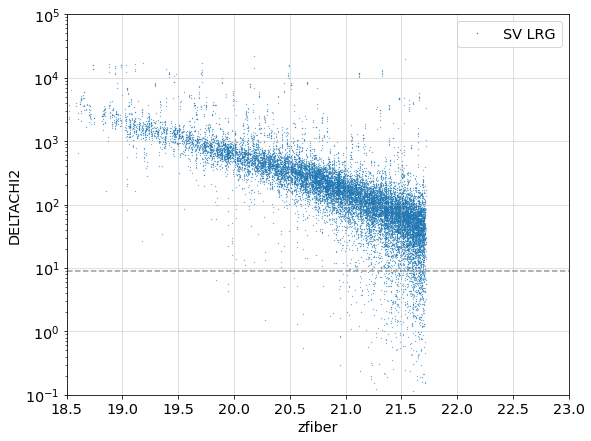

In [20]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_sv3], zbest['DELTACHI2'][lrg_sv3], '.', ms=0.5, alpha=1, label='SV LRG', zorder=0)
plt.axhline(9., ls='--', color='0.6', label=None)
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()